## 1. Librerías

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

## 2. Carga y Procesamiento de Datos

In [19]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../inputs/dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 643
Rango temporal: 2023-01-02 a 2025-08-27


In [20]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [21]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [22]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(514, 60)
(129, 60)


## 4. Optimización de Hiperparámetros con RandomizedSearchCV

In [23]:
# Con 515 días de entrenamiento, podemos usar más pliegues y validaciones más largas
# - n_splits=5: cinco validaciones para una estimación más robusta
# - test_size=20: ~1 mes de validación por fold
# - gap=5: separación temporal entre train y test para evitar fuga de información

max_lag = 5
test_size = 20
tscv = TimeSeriesSplit(n_splits=5, test_size=test_size, gap=max_lag)

In [24]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parámetros ajustados para dataset con ~515 observaciones
param_distributions = {
    "n_estimators": randint(200, 600),        # Más árboles con más datos
    "max_depth": randint(5, 20),              # Mayor profundidad permitida
    "min_samples_split": randint(10, 50),     # Más conservador para evitar overfitting
    "min_samples_leaf": randint(5, 30),       # Hojas más grandes
    "max_features": uniform(0.2, 0.5),        # Más features consideradas por split
    "bootstrap": [True]
}

# Configuración de RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=100,                              # Más iteraciones para explorar mejor el espacio
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # Reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # Útil para auditar overfitting
    error_score=np.nan                       # Si algún fold falla, no aborta toda la búsqueda
)

In [25]:
search.fit(X_train, y_train)

best_rf = search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor CV RMSE: {-search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in search.best_params_.items():
    print(f"  - {param}: {value}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

RESULTADOS DE LA OPTIMIZACIÓN

Mejor CV RMSE: 261625.1122

Mejores hiperparámetros:
  - bootstrap: True
  - max_depth: 15
  - max_features: 0.6707324043882625
  - min_samples_leaf: 7
  - min_samples_split: 10
  - n_estimators: 367


## 5. Evaluación en Test Set

### 5.1. Test del mejor modelo

In [26]:
y_pred = best_rf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Holdout RMSE: 106839.1041
Holdout R²:   0.3211
Error relativo (holdout): 4.84%


### 5.2. Visualización de predicciones

In [27]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

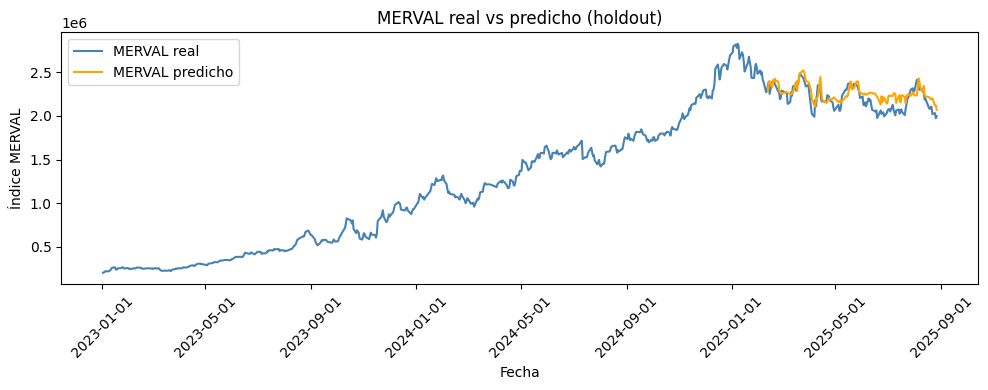

In [28]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


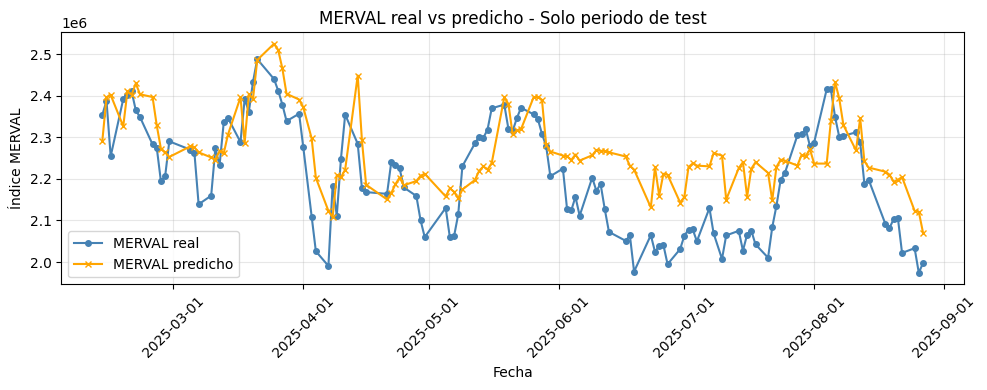

In [29]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3. Análisis de residuales

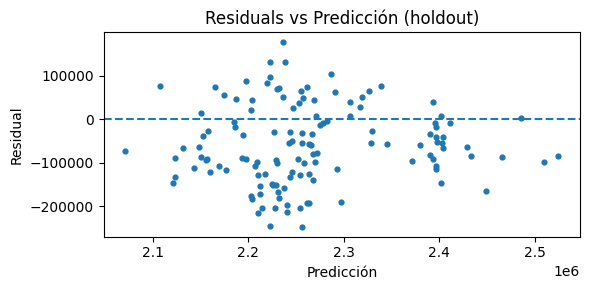

In [30]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


### 5.4. Importancia de variables

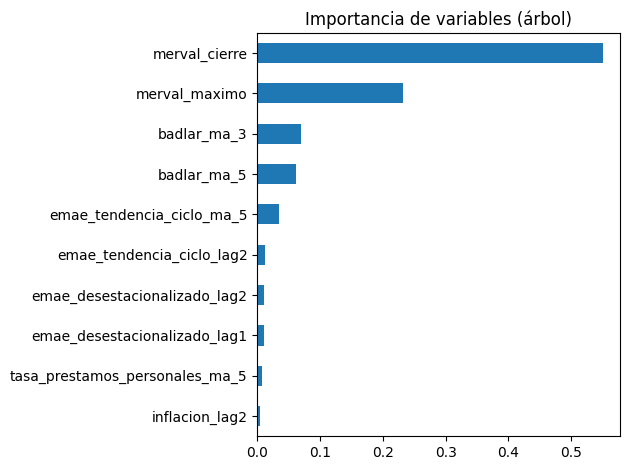

In [31]:
# Importancia de las variables

imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(10).plot(kind="barh", title="Importancia de variables (árbol)")
plt.tight_layout(); plt.show()


### 5.5. Performance en Trading

In [32]:
df_test_eval = df_test[['merval','pred_merval']].copy()

df_test_eval['var_merval'] = (df_test_eval['merval'].pct_change() * 100).round(2)
df_test_eval['var_pred_merval'] = (df_test_eval['pred_merval'].pct_change() * 100).round(2)

df_test_eval['acierta_tendencia'] = (
    (df_test_eval['var_merval'] > 0) & (df_test_eval['var_pred_merval'] > 0)
) | (
    (df_test_eval['var_merval'] < 0) & (df_test_eval['var_pred_merval'] < 0)
)


In [33]:
# Calcular proporción de aciertos
proporcion_aciertos = df_test_eval['acierta_tendencia'].sum() / df_test_eval['acierta_tendencia'].notna().sum()

print(f"Proporción de aciertos en tendencia: {proporcion_aciertos:.2%}")
print(f"Total de predicciones: {df_test_eval['acierta_tendencia'].notna().sum()}")
print(f"Aciertos: {df_test_eval['acierta_tendencia'].sum()}")
print(f"Errores: {(~df_test_eval['acierta_tendencia']).sum()}")

Proporción de aciertos en tendencia: 48.06%
Total de predicciones: 129
Aciertos: 62
Errores: 67


In [35]:
# Análisis de aciertos por tipo de movimiento (subida vs bajada)
# Filtrar datos válidos (sin NaN)
df_valido = df_test_eval.dropna(subset=['var_merval', 'var_pred_merval'])

# Identificar subidas y bajadas reales
subidas_reales = df_valido['var_merval'] > 0
bajadas_reales = df_valido['var_merval'] < 0

# Calcular aciertos en subidas
aciertos_subidas = ((df_valido['var_merval'] > 0) & (df_valido['var_pred_merval'] > 0)).sum()
total_subidas = subidas_reales.sum()
pct_aciertos_subidas = (aciertos_subidas / total_subidas * 100) if total_subidas > 0 else 0

# Calcular aciertos en bajadas
aciertos_bajadas = ((df_valido['var_merval'] < 0) & (df_valido['var_pred_merval'] < 0)).sum()
total_bajadas = bajadas_reales.sum()
pct_aciertos_bajadas = (aciertos_bajadas / total_bajadas * 100) if total_bajadas > 0 else 0

print(f"\nSUBIDAS:")
print(f"  Total de subidas reales: {total_subidas}")
print(f"  Subidas predichas correctamente: {aciertos_subidas}")
print(f"  Porcentaje de acierto: {pct_aciertos_subidas:.2f}%")
print(f"\nBAJADAS:")
print(f"  Total de bajadas reales: {total_bajadas}")
print(f"  Bajadas predichas correctamente: {aciertos_bajadas}")
print(f"  Porcentaje de acierto: {pct_aciertos_bajadas:.2f}%")


SUBIDAS:
  Total de subidas reales: 62
  Subidas predichas correctamente: 25
  Porcentaje de acierto: 40.32%

BAJADAS:
  Total de bajadas reales: 65
  Bajadas predichas correctamente: 37
  Porcentaje de acierto: 56.92%


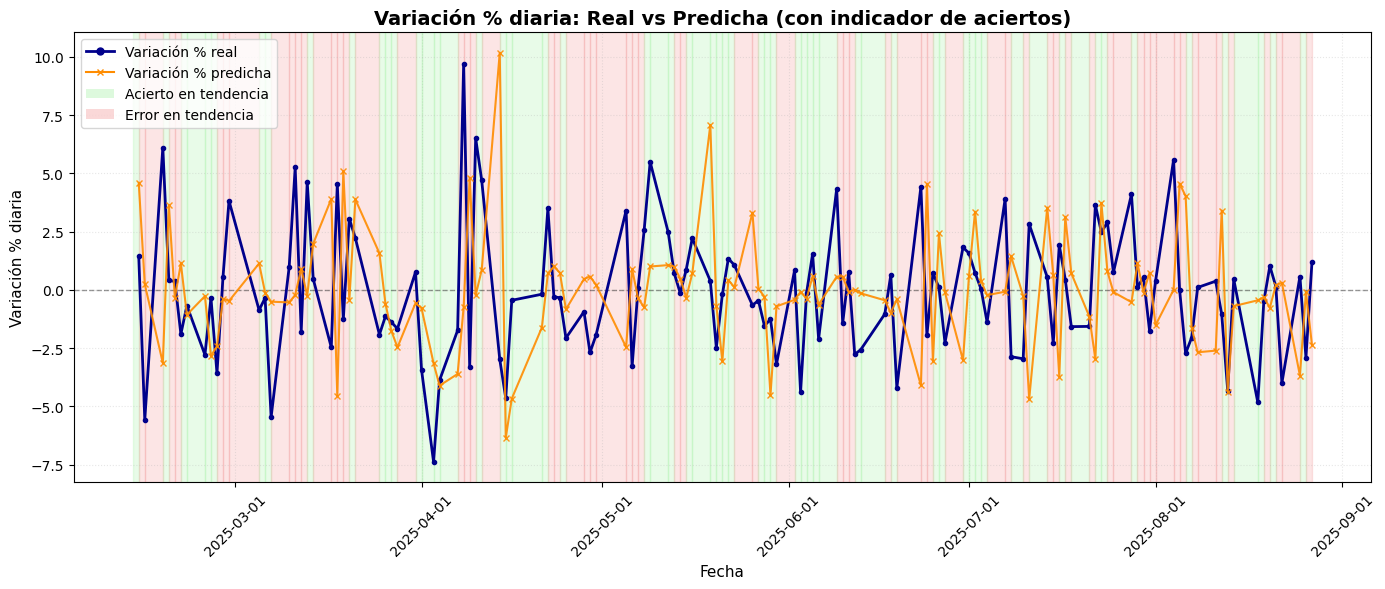

In [34]:
# Gráfico de variaciones porcentuales con fondo coloreado según aciertos
fig, ax = plt.subplots(figsize=(14, 6))

# Convertir índice a timestamp para graficar
fechas = df_test_eval.index.to_timestamp()

# Agregar fondo de colores según aciertos/errores
for i in range(1, len(df_test_eval)):
    if pd.notna(df_test_eval['acierta_tendencia'].iloc[i]):
        color = 'lightgreen' if df_test_eval['acierta_tendencia'].iloc[i] else 'lightcoral'
        ax.axvspan(fechas[i-1], fechas[i], alpha=0.2, color=color)

# Plotear las variaciones
ax.plot(fechas, df_test_eval['var_merval'], label='Variación % real', 
        color='darkblue', marker='o', markersize=3, linewidth=2, zorder=3)
ax.plot(fechas, df_test_eval['var_pred_merval'], label='Variación % predicha', 
        color='darkorange', marker='x', markersize=4, linewidth=1.5, alpha=0.9, zorder=3)

# Línea en 0 para referencia
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.4, zorder=2)

# Leyenda personalizada para incluir los fondos
from matplotlib.patches import Patch
legend_elements = [
    plt.Line2D([0], [0], color='darkblue', marker='o', markersize=5, linewidth=2, label='Variación % real'),
    plt.Line2D([0], [0], color='darkorange', marker='x', markersize=5, linewidth=1.5, label='Variación % predicha'),
    Patch(facecolor='lightgreen', alpha=0.3, label='Acierto en tendencia'),
    Patch(facecolor='lightcoral', alpha=0.3, label='Error en tendencia')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

ax.set_title("Variación % diaria: Real vs Predicha (con indicador de aciertos)", fontsize=14, fontweight='bold')
ax.set_xlabel("Fecha", fontsize=11)
ax.set_ylabel("Variación % diaria", fontsize=11)
ax.grid(True, alpha=0.3, zorder=1, linestyle=':')

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Conclusiones

### Resultados principales

- **RMSE en test**: 106,839.10 - El modelo logra un error cuadrático medio razonable considerando la alta volatilidad del MERVAL.

- **R² en test**: 0.3211 - El modelo explica aproximadamente el 32.1% de la varianza del MERVAL en el test set, demostrando capacidad predictiva moderada y superando significativamente a un modelo trivial que predice la media.

- **Error relativo**: 4.84% - En promedio, las predicciones se desvían ~4.84% del valor real del MERVAL, lo cual es aceptable para un índice financiero con alta volatilidad.

### Optimización de hiperparámetros

- Se utilizó **RandomizedSearchCV** con 100 iteraciones y validación cruzada temporal (TimeSeriesSplit con 5 folds).
- **CV RMSE**: 261,625.11 - Error promedio en validación cruzada.
- Los mejores parámetros encontrados:
  - `n_estimators=367`: conjunto grande de árboles para mayor estabilidad en las predicciones
  - `max_depth=15`: árboles profundos que permiten capturar relaciones complejas entre variables
  - `max_features=0.67`: aproximadamente 40 features consideradas en cada split
  - `min_samples_split=10` y `min_samples_leaf=7`: regularización moderada para evitar overfitting

### Variables más importantes

Según el gráfico de importancia de variables, las features más relevantes incluyen:
- **Variables históricas del MERVAL**: valores de cierre y máximos previos son predictores clave
- **Indicadores macroeconómicos transformados**: moving averages, diferenciaciones y componentes espectrales
- **Variables monetarias y crediticias**: tasas, base monetaria, M1/M2, y créditos privados

### Fortalezas del modelo

1. **Capacidad predictiva positiva**: R² > 0 indica que el modelo supera significativamente al baseline de predecir la media.

2. **Robustez del ensemble**: El uso de 367 árboles con bootstrap proporciona predicciones estables y reduce la varianza.

3. **Control de overfitting**: La validación cruzada temporal y los parámetros de regularización aseguran buena generalización.

4. **Interpretabilidad**: La importancia de variables permite entender qué features impulsan las predicciones.

### Limitaciones y próximos pasos

1. **Diferencia CV vs Holdout**: El RMSE de validación cruzada (261,625) es considerablemente mayor que el de test (106,839), sugiriendo que el periodo de test fue relativamente más predecible o que algunos folds de CV incluyeron períodos de alta volatilidad.

2. **Varianza no explicada**: ~68% de la varianza permanece sin explicar, lo cual es esperado dada la naturaleza estocástica de los mercados financieros.

3. **Posibles mejoras**:
   - Experimentar con modelos específicos para series temporales (ARIMA, Prophet, LSTM)
   - Explorar diferentes ventanas temporales para las features de moving averages
   - Agregar features de sentiment analysis o indicadores técnicos adicionales
   - Investigar regímenes de mercado (alcista/bajista) para modelado condicional
   - Implementar ensemble con otros algoritmos (stacking/blending)

4. **Validación adicional**: Evaluar con walk-forward validation para simular condiciones de producción real y confirmar la capacidad de generalización.